In [33]:
import matplotlib.pyplot as plt
from torch import optim
import torch
import torch.nn as nn 
from torch.utils.data import Dataset, DataLoader

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor



device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
# print("Model device:", next(classifier.parameters()).device)


Using device: cuda


In [42]:
class BaseClassifier(nn.Module):
       def __init__(self, in_dim, feature_dim, out_dim):
              super(BaseClassifier, self).__init__()
              self.classifier = nn.Sequential(

                     nn.Linear(in_dim, feature_dim, bias= True, device=device),
                     nn.ReLU(),
                     nn.Linear(feature_dim, out_dim, bias=True, device= device)
              )

       def forward(self, x):
              return self.classifier(x)
       

       #  Loading the mnist dataset

train_dataset = MNIST(".", train= True, download= True, transform=ToTensor())
test_dataset = MNIST(".", train = False, download = True, transform= ToTensor())

train_loader = DataLoader(train_dataset, batch_size= 64, shuffle = True)
test_loader =  DataLoader(test_dataset, batch_size= 64,  shuffle = False)





In [43]:
#  instantiate the model parameters

inDim, featureDim, outDim = 784, 256, 10

lr = 1e-3

loss_fn = nn.CrossEntropyLoss()

epochs = 40

classifier = BaseClassifier(inDim, featureDim, outDim)
optimizer = optim.SGD(classifier.parameters(), lr= lr)

In [44]:
def train(classifier = classifier, optimizer = optimizer, epochs = epochs, loss_fn = loss_fn):
       classifier.train()
       loss_lt = []
       for epoch in range(epochs):
              runningLoss = 0.0
              for minibatch in train_loader:

                     data, target = minibatch
                     data = data.to(device)
                     target = target.to(device)
                     data = data.flatten(start_dim =1)
                     out = classifier(data)
                     computed_loss = loss_fn(out, target)
                     optimizer.zero_grad()
                     computed_loss.backward()
                     optimizer.step()
                     


                     # keeping track of sum of loss of each minibatch

                     runningLoss += computed_loss.item()
              loss_lt.append(runningLoss/len(train_loader))
              print("Epoch: {} trainLoss {} ".format(epoch+1, runningLoss/len(train_loader)))

       plt.plot([i for i in range(1, epochs+1)], loss_lt)
       plt.ylabel("Training Loss")
       plt.xlabel("Epoch")
       plt.title("MNIST Training loss: optimizer {}, lr {}".format("SGD", lr))
       plt.show()


       torch.save(classifier.state_dict(), 'mnist.pt')



In [49]:
def test(classifier = classifier, loss_fn = loss_fn):
       classifier.eval()
       accuracy =0.0
       computed_loss = 0.0

       with torch.no_grad():
              for data, target in test_loader:
                     data = data.to(device)
                     target = target.to(device)
                     data = data.flatten(start_dim =1)
                     out = classifier(data)
                     _, pred = out.max(dim =1)

                     computed_loss += loss_fn(out, target)
                     accuracy =+ torch.sum(pred==target)

              print("Test Loss: {}, Test Accurcy: {}".format(computed_loss.item()/(len(test_loader))*64, accuracy*100/(len(test_loader))*64))

Epoch: 1 trainLoss 2.2133261211899553 
Epoch: 2 trainLoss 1.987504647103454 
Epoch: 3 trainLoss 1.6900016279108743 
Epoch: 4 trainLoss 1.3800262330945876 
Epoch: 5 trainLoss 1.1261229258356318 
Epoch: 6 trainLoss 0.9453640288508522 
Epoch: 7 trainLoss 0.8205936282936698 
Epoch: 8 trainLoss 0.7324225042166232 
Epoch: 9 trainLoss 0.6675544036413307 
Epoch: 10 trainLoss 0.618360331730802 
Epoch: 11 trainLoss 0.5796090976071002 
Epoch: 12 trainLoss 0.5484515015186786 
Epoch: 13 trainLoss 0.5228458992771502 
Epoch: 14 trainLoss 0.5015398505558846 
Epoch: 15 trainLoss 0.4833521242461987 
Epoch: 16 trainLoss 0.4679953230342377 
Epoch: 17 trainLoss 0.4545628829742037 
Epoch: 18 trainLoss 0.44283854413324836 
Epoch: 19 trainLoss 0.43238161292983524 
Epoch: 20 trainLoss 0.42307744240328704 
Epoch: 21 trainLoss 0.4146527867835722 
Epoch: 22 trainLoss 0.4071726889879719 
Epoch: 23 trainLoss 0.40038626531420995 
Epoch: 24 trainLoss 0.3940675454194358 
Epoch: 25 trainLoss 0.3882559130726847 
Epoch: 

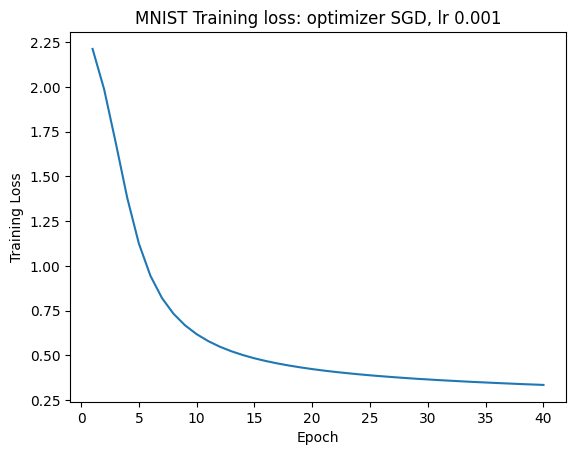

In [46]:
train()

In [50]:
test()

Test Loss: 20.408854685011942, Test Accurcy: 611.4649658203125


In [28]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# import matplotlib.pyplot as plt

# from torchvision.datasets import MNIST
# from torchvision.transforms import ToTensor
# from torch.utils.data import DataLoader

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# class BaseClassifier(nn.Module):
#     def __init__(self, in_dim, feature_dim, out_dim):
#         super(BaseClassifier, self).__init__()
#         self.classifier = nn.Sequential(
#             nn.Linear(in_dim, feature_dim),
#             nn.ReLU(),
#             nn.Linear(feature_dim, out_dim)
#         )

#     def forward(self, x):
#         return self.classifier(x)


# # Loading MNIST dataset
# train_dataset = MNIST(".", train=True, download=True, transform=ToTensor())
# test_dataset  = MNIST(".", train=False, download=True, transform=ToTensor())

# train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
# test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)


# # Hyperparameters
# inDim, featureDim, outDim = 784, 256, 10
# lr = 1e-3
# epochs = 40

# loss_fn = nn.CrossEntropyLoss()

# classifier = BaseClassifier(inDim, featureDim, outDim).to(device)
# optimizer = optim.SGD(classifier.parameters(), lr=lr)


# def train():
#     classifier.train()
#     loss_lt = []

#     for epoch in range(epochs):
#         runningLoss = 0.0

#         for data, target in train_loader:
#             data = data.to(device)
#             target = target.to(device)

#             data = data.flatten(start_dim=1)

#             optimizer.zero_grad()
#             out = classifier(data)
#             loss = loss_fn(out, target)
#             loss.backward()
#             optimizer.step()

#             runningLoss += loss.item()

#         avg_loss = runningLoss / len(train_loader)
#         loss_lt.append(avg_loss)

#         print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_loss:.4f}")

#     plt.plot(range(1, epochs + 1), loss_lt)
#     plt.ylabel("Training Loss")
#     plt.xlabel("Epoch")
#     plt.title(f"MNIST Training Loss (SGD, lr={lr})")
#     plt.show()

#     torch.save(classifier.state_dict(), "mnist.pt")


# def test():
#     classifier.eval()
#     total_correct = 0
#     total_samples = 0
#     total_loss = 0.0

#     with torch.no_grad():
#         for data, target in test_loader:
#             data = data.to(device)
#             target = target.to(device)

#             data = data.flatten(start_dim=1)

#             out = classifier(data)
#             loss = loss_fn(out, target)
#             total_loss += loss.item()

#             pred = out.argmax(dim=1)
#             total_correct += (pred == target).sum().item()
#             total_samples += target.size(0)

#     avg_loss = total_loss / len(test_loader)
#     acc = 100.0 * total_correct / total_samples

#     print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {acc:.2f}%")
